# CeNNMixer-v4 — DeltaCell

CeNNMixer-v4 is a structural correction of v3.

v3 reached alpha=0.6 but generation collapsed even while mixer MSE kept improving.
The missing mechanisms are important parts of Qwen3.5 Gated DeltaNet itself.

v4 combines:

- compact CeNN fast / mid / slow cellular state
- causal depthwise convolution, kernel 4
- normalized q/k content addressing
- compact matrix fast-weight state
- per-token beta update strength
- per-token recurrent decay
- delta-rule correction
- gated RMS-normalized associative output
- top-1 margin distillation
- forward + reverse KL
- on-policy distillation on student-generated prefixes

Default compact associative state:

    8 heads × 32 key dim × 64 value dim

versus Qwen3.5 native linear-attention state:

    16 heads × 128 key dim × 128 value dim

The first target is still only layer 0.


In [1]:
#@title 1. Setup
import pathlib, subprocess, sys, importlib, json, torch, shutil

REPO_DIR=pathlib.Path('/content/TinyCeNN-LM')
if REPO_DIR.exists():
    subprocess.run(['git','-C',str(REPO_DIR),'fetch','origin'],check=True)
    subprocess.run(['git','-C',str(REPO_DIR),'reset','--hard','origin/main'],check=True)
else:
    subprocess.run(['git','clone','https://github.com/vtavakkoli/TinyCeNN-LM.git',str(REPO_DIR)],check=True)

subprocess.run([
    sys.executable,'-m','pip','install','-q','-U',
    'transformers','accelerate','datasets','pandas','matplotlib',
    'huggingface_hub','safetensors'
],check=True)
subprocess.run([sys.executable,'-m','pip','install','-q','-e',str(REPO_DIR)],check=True)

SRC=REPO_DIR/'src'
if str(SRC) not in sys.path:
    sys.path.insert(0,str(SRC))
for n in list(sys.modules):
    if n=='tinycenn_lm' or n.startswith('tinycenn_lm.'):
        del sys.modules[n]
importlib.invalidate_caches()

for p in [
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_cennmixer_v4_core.py',
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_cennmixer_v4.py',
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_cennmixer_v4_train.py',
    REPO_DIR/'scripts'/'run_qwen35_cennmixer_v4.py',
]:
    subprocess.run([sys.executable,'-m','py_compile',str(p)],check=True)

print('✓ CeNNMixer-v4 preflight OK')
print('CUDA:',torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:',torch.cuda.get_device_name(0))
else:
    print('⚠️ Select a GPU runtime.')


✓ CeNNMixer-v4 preflight OK
CUDA: True
GPU: Tesla T4


In [2]:
#@title 2. Configuration
BASE_MODEL='Qwen/Qwen3.5-0.8B' #@param {type:'string'}
LAYERS='0' #@param {type:'string'}
QUICK_SMOKE=True #@param {type:'boolean'}
EXPLORE_HIGH_ALPHA=True #@param {type:'boolean'}
RESUME_ALPHA=-1.0 #@param {type:'number'}

# CeNN local branch
GROUPS=24 #@param {type:'integer'}
CELL_DIM=32 #@param {type:'integer'}
GRAPH_STEPS=1 #@param {type:'integer'}

# DeltaCell associative branch
ASSOC_HEADS=8 #@param {type:'integer'}
KEY_DIM=32 #@param {type:'integer'}
VALUE_DIM=64 #@param {type:'integer'}
CONV_KERNEL=4 #@param {type:'integer'}

LR=0.0002 #@param {type:'number'}
ON_POLICY_EVERY=40 #@param {type:'integer'}
ON_POLICY_TOKENS=12 #@param {type:'integer'}

# Full-run values. Quick mode overrides the data/training budget.
ALPHAS='0,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,1.0' #@param {type:'string'}
SEQ_LEN=128 #@param {type:'integer'}
TRAIN_BLOCKS=1536 #@param {type:'integer'}
VAL_BLOCKS=48 #@param {type:'integer'}
STAGE_UPDATES=300 #@param {type:'integer'}
EXTEND_UPDATES=200 #@param {type:'integer'}
MAX_STAGE_UPDATES=3000 #@param {type:'integer'}
PROBE_EVERY=50 #@param {type:'integer'}
PATIENCE_PROBES=8 #@param {type:'integer'}
MIN_LR=0.0000125 #@param {type:'number'}
TOPK=64 #@param {type:'integer'}

MIN_TOP1=0.97 #@param {type:'number'}
MAX_KL=0.03 #@param {type:'number'}
MAX_HIDDEN_MSE=0.05 #@param {type:'number'}
MAX_MIXER_MSE=0.12 #@param {type:'number'}

OUTPUT_DIR=REPO_DIR/'results'/'cennmixer_v4_qwen35_08b'

print('Quick smoke:',QUICK_SMOKE)
print('Explore higher alpha after soft misses:',EXPLORE_HIGH_ALPHA)
print('Resume alpha (-1 means fresh run):',RESUME_ALPHA)
print('CeNN local:',GROUPS,'×',CELL_DIM)
print('DeltaCell state:',ASSOC_HEADS,'×',KEY_DIM,'×',VALUE_DIM)
print('Runtime associative state floats:',ASSOC_HEADS*KEY_DIM*VALUE_DIM)


Quick smoke: True
CeNN local: 24 × 32
DeltaCell state: 8 × 32 × 64
Runtime associative state floats: 16384


### Quick v4 test

Quick mode now uses finer steps once CeNN starts taking substantial control:

    0 → .10 → .20 → .30 → .40
      → .45 → .50 → .55 → .60 → .65
      → .70 → .75 → .80 → .85 → .90 → .95 → 1.0

With `EXPLORE_HIGH_ALPHA=True`, a stage may continue even if it narrowly misses
the normal smoke gate, provided the numerical model remains stable:

    violation <= 0.20
    top1 >= 0.82
    KL <= 0.20
    hidden MSE <= 0.18
    mixer MSE <= 0.30
    mixer cosine <= 0.15
    mixer delta <= 0.45

Generation Jaccard is still reported, but it is **not a hard continuation gate**
because five short prompts are too noisy to decide whether an architecture can
be explored at the next alpha.

On-policy distillation is again performed every 40 updates. A single on-policy
loss is dynamically capped in effective magnitude, so spikes from a poor sampled
prefix cannot dominate one optimizer step.

The strict scientific final gate is unchanged.


### Resume directly from your current alpha=0.4 checkpoint

If you are still in the same Colab runtime that produced the latest run, set:

    RESUME_ALPHA = 0.4
    EXPLORE_HIGH_ALPHA = True

The runner will load:

    results/cennmixer_v4_qwen35_08b/cennmixer_v4_alpha_0p4_best.pt

and start directly at alpha=0.5.

If you restarted the Colab runtime and the results directory is gone, leave `RESUME_ALPHA=-1` and run from alpha=0 again.


In [3]:
#@title 3. Train CeNNMixer-v4
cmd=[
    sys.executable,'-u',str(REPO_DIR/'scripts'/'run_qwen35_cennmixer_v4.py'),
    '--base-model',BASE_MODEL,
    '--layers',LAYERS,
    '--alphas',ALPHAS,
    '--seq-len',str(SEQ_LEN),
    '--train-blocks',str(TRAIN_BLOCKS),
    '--val-blocks',str(VAL_BLOCKS),
    '--groups',str(GROUPS),
    '--cell-dim',str(CELL_DIM),
    '--graph-steps',str(GRAPH_STEPS),
    '--assoc-heads',str(ASSOC_HEADS),
    '--key-dim',str(KEY_DIM),
    '--value-dim',str(VALUE_DIM),
    '--conv-kernel',str(CONV_KERNEL),
    '--lr',str(LR),
    '--stage-updates',str(STAGE_UPDATES),
    '--extend-updates',str(EXTEND_UPDATES),
    '--max-stage-updates',str(MAX_STAGE_UPDATES),
    '--probe-every',str(PROBE_EVERY),
    '--patience-probes',str(PATIENCE_PROBES),
    '--min-lr',str(MIN_LR),
    '--topk',str(TOPK),
    '--on-policy-every',str(ON_POLICY_EVERY),
    '--on-policy-tokens',str(ON_POLICY_TOKENS),
    '--min-top1',str(MIN_TOP1),
    '--max-kl',str(MAX_KL),
    '--max-hidden-mse',str(MAX_HIDDEN_MSE),
    '--max-mixer-mse',str(MAX_MIXER_MSE),
    '--output-dir',str(OUTPUT_DIR),
]
if QUICK_SMOKE:
    cmd.append('--quick-smoke')
if EXPLORE_HIGH_ALPHA:
    cmd.append('--explore-high-alpha')
if RESUME_ALPHA >= 0:
    cmd += ['--resume-alpha',str(RESUME_ALPHA)]

print('='*120)
print(' '.join(cmd))
print('='*120)

p=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,bufsize=1)
for line in iter(p.stdout.readline,''):
    print(line,end='',flush=True)
rc=p.wait()
print('\nFinished, exit code',rc)
if rc:
    raise subprocess.CalledProcessError(rc,cmd)


/usr/bin/python3 -u /content/TinyCeNN-LM/scripts/run_qwen35_cennmixer_v4.py --base-model Qwen/Qwen3.5-0.8B --layers 0 --alphas 0,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,1.0 --seq-len 128 --train-blocks 1536 --val-blocks 48 --groups 24 --cell-dim 32 --graph-steps 1 --assoc-heads 8 --key-dim 32 --value-dim 64 --conv-kernel 4 --lr 0.0002 --stage-updates 300 --extend-updates 200 --max-stage-updates 3000 --probe-every 50 --patience-probes 8 --min-lr 1.25e-05 --topk 64 --on-policy-every 40 --on-policy-tokens 12 --min-top1 0.97 --max-kl 0.03 --max-hidden-mse 0.05 --max-mixer-mse 0.12 --output-dir /content/TinyCeNN-LM/results/cennmixer_v4_qwen35_08b --quick-smoke
QUICK_SMOKE V4 {'alphas': '0,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,1.0', 'seq_len': 64, 'train_blocks': 384, 'val_blocks': 16, 'assoc': '8x32x64', 'conv_kernel': 4, 'on_policy_every': 40}
DEVICE cuda dtype torch.bfloat16 layers [0] alphas [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

Loading weights: 100%|█

In [4]:
#@title 4. Results and parameter reduction
import pandas as pd
from IPython.display import display

report=json.loads((OUTPUT_DIR/'report.json').read_text())
stage=pd.read_csv(OUTPUT_DIR/'stage_summary.csv')
hist=pd.read_csv(OUTPUT_DIR/'training_history.csv')

print('Architecture:',report['architecture'])
print('Reached alpha:',report['reached_alpha'])
print('Progression complete:',report['progression_complete'])
print('Exploration mode:',report.get('exploration_mode'))
print('Exploration reached alpha:',report.get('exploration_reached_alpha'))
print('Strict final quality:',report['strict_quality_gate'])
print('CeNN-v4 params:',f"{report['cenn_params']:,}")
print('Qwen mixer params:',f"{report['replaced_qwen_mixer_params']:,}")
print('Mixer parameter reduction:',f"{report['mixer_param_reduction_pct']:.2f}%")

display(stage[[
    'alpha','best_step','trained_steps','pass','exploration_continue','violation',
    'student_ce','ce_gap','kl','reverse_kl','hidden_mse','delta_mse',
    'mixer_mse','mixer_cosine','mixer_delta','top1','top1_margin_loss',
    'generation_exact_rate','generation_mean_jaccard','generation_warning'
]])


Architecture: CeNNMixer-v4 DeltaCell: CeNN + compact gated-delta matrix memory
Reached alpha: 0.4
Progression complete: False
Strict final quality: False
CeNN-v4 params: 5,415,609
Qwen mixer params: 10,543,264
Mixer parameter reduction: 48.63%


,alpha,best_step,trained_steps,pass,violation,student_ce,ce_gap,kl,reverse_kl,hidden_mse,delta_mse,mixer_mse,mixer_cosine,mixer_delta,top1,top1_margin_loss,generation_exact_rate,generation_mean_jaccard
0,0.0,280,280,True,0.000000,4.023560,0.000000,-3.293048e-09,0.000000,0.000000,0.000000,0.249306,0.128781,0.369273,1.000000,0.002100,1.0,1.000000
1,0.1,0,0,True,0.000000,4.013383,-0.010177,4.130937e-03,0.004126,0.004120,0.005062,0.249306,0.128781,0.369273,0.964844,0.034167,0.8,0.991304
2,0.2,0,0,True,0.000000,4.015214,-0.008347,1.481292e-02,0.015275,0.015891,0.019511,0.249306,0.128781,0.369273,0.942383,0.063623,0.2,0.792490
3,0.3,0,0,True,0.000000,4.024488,0.000928,3.488358e-02,0.038071,0.035881,0.044087,0.249306,0.128781,0.369273,0.919922,0.104980,0.0,0.470524
4,0.4,240,240,False,0.071374,4.039381,0.015821,5.347251e-02,0.057779,0.054280,0.067069,0.228292,0.117916,0.340604,0.889648,0.144324,0.0,0.314442


In [5]:
#@title 5. Compare directly with CeNNMixer-v3
V3_ALPHA06={
    'top1':0.84765625,
    'kl':0.1179187144,
    'hidden_mse':0.0986091695,
    'mixer_mse':0.1808171482,
    'generation_jaccard':0.1597098516,
}

print('v3 reference at alpha=0.6:',V3_ALPHA06)
for a in [0.5,0.6,0.7]:
    row=stage[(stage['alpha']-a).abs()<1e-9]
    if len(row):
        r=row.iloc[0]
        print(f"\nv4 alpha={a:g}")
        print(' top1:',float(r.top1))
        print(' KL:',float(r.kl))
        print(' hidden MSE:',float(r.hidden_mse))
        print(' mixer MSE:',float(r.mixer_mse))
        print(' generation Jaccard:',float(r.generation_mean_jaccard))

if len(stage[(stage['alpha']-0.6).abs()<1e-9]):
    r=stage[(stage['alpha']-0.6).abs()<1e-9].iloc[0]
    print('\nΔ v4-v3 at alpha=0.6:')
    print(' top1:',float(r.top1)-V3_ALPHA06['top1'])
    print(' generation Jaccard:',float(r.generation_mean_jaccard)-V3_ALPHA06['generation_jaccard'])


v3 reference at alpha=0.6: {'top1': 0.84765625, 'kl': 0.1179187144, 'hidden_mse': 0.0986091695, 'mixer_mse': 0.1808171482, 'generation_jaccard': 0.1597098516}


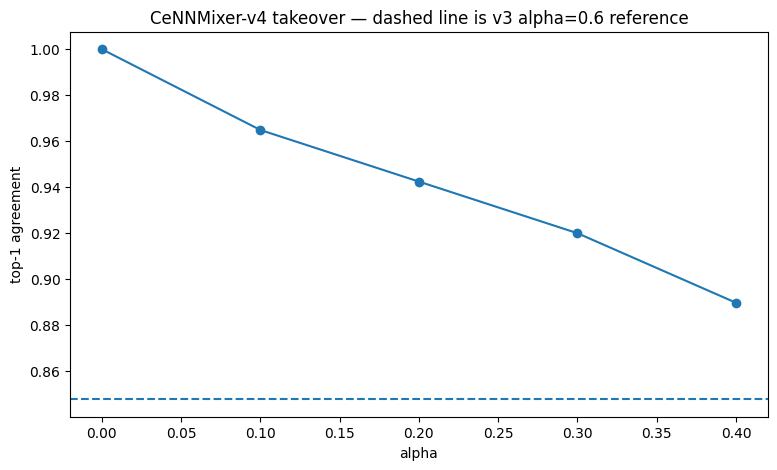

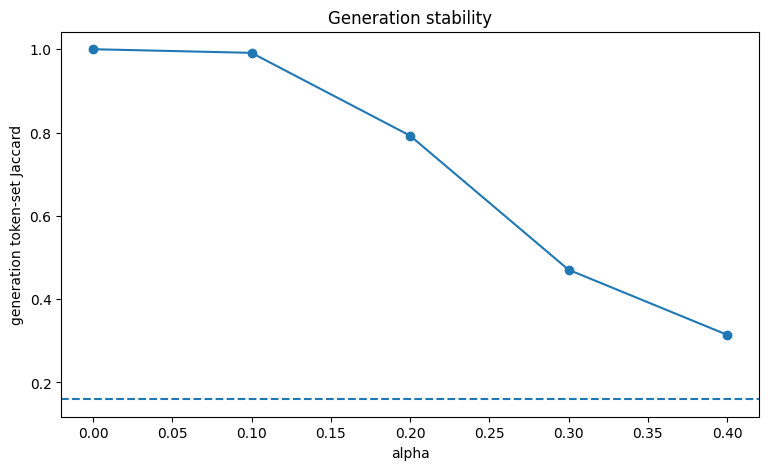

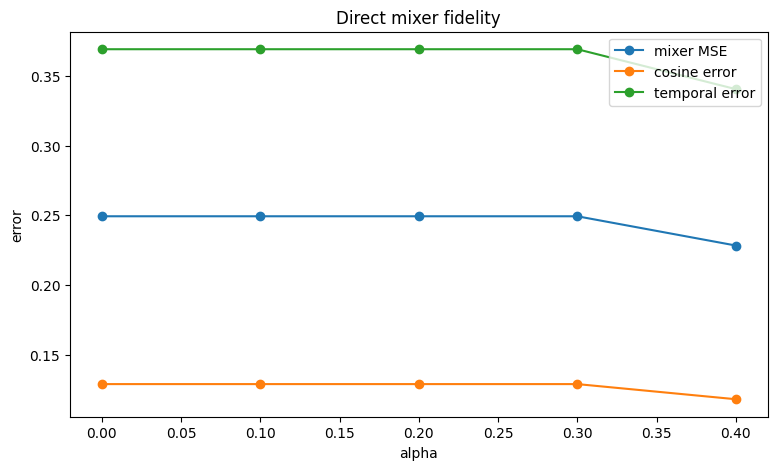

In [6]:
#@title 6. Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.plot(stage['alpha'],stage['top1'],marker='o')
plt.axhline(V3_ALPHA06['top1'],linestyle='--')
plt.xlabel('alpha')
plt.ylabel('top-1 agreement')
plt.title('CeNNMixer-v4 takeover — dashed line is v3 alpha=0.6 reference')
plt.show()

plt.figure(figsize=(9,5))
plt.plot(stage['alpha'],stage['generation_mean_jaccard'],marker='o')
plt.axhline(V3_ALPHA06['generation_jaccard'],linestyle='--')
plt.xlabel('alpha')
plt.ylabel('generation token-set Jaccard')
plt.title('Generation stability')
plt.show()

plt.figure(figsize=(9,5))
plt.plot(stage['alpha'],stage['mixer_mse'],marker='o',label='mixer MSE')
plt.plot(stage['alpha'],stage['mixer_cosine'],marker='o',label='cosine error')
plt.plot(stage['alpha'],stage['mixer_delta'],marker='o',label='temporal error')
plt.xlabel('alpha')
plt.ylabel('error')
plt.legend()
plt.title('Direct mixer fidelity')
plt.show()


### Hard pass vs exploration continuation

- `pass=True`: the normal smoke-stage thresholds were satisfied.
- `exploration_continue=True`: the stage missed the normal threshold, but stayed coherent enough to continue testing larger alpha.
- Neither one changes the final scientific acceptance thresholds.
- Hugging Face upload remains blocked unless the final CeNN-only model passes the strict quality gate.


In [7]:
#@title 7. Final / latest generation samples
if report.get('progression_complete'):
    rows=report['final_cenn_only_generation']
    print('Final CeNN-only generation:')
else:
    last=float(stage.iloc[-1]['alpha'])
    path=OUTPUT_DIR/f"generation_alpha_{str(last).replace('.','p')}.json"
    rows=json.loads(path.read_text())
    print('Progression stopped at alpha',last,'— showing latest best generation.')

for i,x in enumerate(rows,1):
    print('\n'+'='*100)
    print(i,'USER:',x['prompt'])
    print('QWEN:',x['qwen'])
    print('CeNN-v4:',x['cenn'])
    print('exact=',x['exact'],'jaccard=',round(x['jaccard'],3))


Progression stopped at alpha 0.4 — showing latest best generation.

1 USER: What is 17 + 25? Give only the answer.
QWEN: 42
CeNN-v4: 17 + 25 = 42

 42

 42

 42
 42
 42
 42 42
exact= False jaccard= 0.364

2 USER: Write one short sentence about Vienna.
QWEN: Vienna is a historic city known for its rich culture, vibrant nightlife, and stunning architecture.
CeNN-v4: Vienna is a city in Austria known for its historic architecture, vibrant culture, and stunning views of the Alps.
r...
exact= False jaccard= 0.643

3 USER: Explain in one sentence what an API is.
QWEN: An API is a set of rules and protocols that allows software applications to communicate with each other.
CeNN-v4: <think>

</think>
exact= False jaccard= 0.08

4 USER: Translate 'Good morning' into German. Give only the translation.
QWEN: Guten Morgen
CeNN-v4: ..........
..
.
.
.
.
.
exact= False jaccard= 0.286

5 USER: The secret number is 81427. Remember it. What is the secret number? Give only the number.
QWEN: 81427
CeNN-v4

In [8]:
#@title 8. Inspect on-policy / margin training
if len(hist):
    cols=[
        'alpha','stage_step','train_forward_kl','train_reverse_kl',
        'train_rank_loss','train_margin_loss','train_on_policy_loss','train_on_policy_scale',
        'top1','top1_margin_loss'
    ]
    display(hist[cols].tail(40))

    used=hist[hist['train_on_policy_loss']>0]
    print('On-policy updates recorded:',len(used))
    if len(used):
        display(used[cols].tail(20))


,alpha,stage_step,train_forward_kl,train_reverse_kl,train_rank_loss,train_margin_loss,train_on_policy_loss,top1,top1_margin_loss
0,0.0,1,-2.416510e-09,0.000000,0.000000,0.000781,0.000000,1.000000,0.002100
1,0.0,20,-5.999850e-09,0.000000,0.000000,0.003906,0.000000,1.000000,0.002100
2,0.0,40,-6.332333e-09,0.000000,0.000000,0.002344,0.000000,1.000000,0.002100
3,0.0,60,2.071463e-10,0.000000,0.000000,0.002344,0.000000,1.000000,0.002100
4,0.0,80,-2.847924e-09,0.000000,0.000000,0.000000,0.000000,1.000000,0.002100
5,0.0,100,-5.019529e-09,0.000000,0.000000,0.002344,0.000000,1.000000,0.002100
6,0.0,120,2.704768e-09,0.000000,0.000000,0.000781,0.000000,1.000000,0.002100
7,0.0,140,-7.440670e-09,0.000000,0.000000,0.000781,0.000000,1.000000,0.002100
8,0.0,160,1.840540e-08,0.000000,0.000000,0.002344,0.000000,1.000000,0.002100
9,0.0,180,-6.733059e-10,0.000000,0.000000,0.002344,0.000000,1.000000,0.002100


On-policy updates recorded: 6


,alpha,stage_step,train_forward_kl,train_reverse_kl,train_rank_loss,train_margin_loss,train_on_policy_loss,top1,top1_margin_loss
17,0.4,40,0.042207,0.056069,0.027066,0.126367,0.029523,0.863281,0.174133
19,0.4,80,0.068945,0.091031,0.062921,0.133398,0.031493,0.873047,0.159473
21,0.4,120,0.058496,0.058256,0.076051,0.171094,0.334677,0.879883,0.150757
23,0.4,160,0.057419,0.057503,0.078908,0.176562,0.092466,0.871094,0.156628
25,0.4,200,0.038057,0.039056,0.043048,0.124023,0.019153,0.881836,0.141992
27,0.4,240,0.072031,0.081771,0.051091,0.123633,0.080161,0.889648,0.144324


In [9]:
#@title 9. Upload strict-quality final v4 model to Hugging Face
from huggingface_hub import HfApi, login
import shutil, json

if not report.get('progression_complete'):
    raise RuntimeError('CeNNMixer-v4 has not safely reached alpha=1; HF upload is blocked.')
if not report.get('strict_quality_gate'):
    raise RuntimeError('CeNN-v4 reached alpha=1 but did not pass the strict quality gate; HF upload is blocked.')

HF_REPO_ID='vtava/Qwen35-0.8B-CeNNMixer-v4-DeltaCell' #@param {type:'string'}
HF_PRIVATE=False #@param {type:'boolean'}

HF_EXPORT=REPO_DIR/'results'/'Qwen35-0.8B-CeNNMixer-v4-DeltaCell-HF'
if HF_EXPORT.exists():
    shutil.rmtree(HF_EXPORT)
HF_EXPORT.mkdir(parents=True,exist_ok=True)

for name in ['cennmixer_v4_final_cenn_only.pt','report.json','stage_summary.csv','training_history.csv']:
    src=OUTPUT_DIR/name
    if src.exists():
        shutil.copy2(src,HF_EXPORT/name)

(HF_EXPORT/'cennmixer_v4_config.json').write_text(json.dumps({
    'base_model':report['base_model'],
    'architecture':report['architecture'],
    'layers':report['layers'],
    'layer_kinds':report['layer_kinds'],
    'config':report['config'],
    'final_metrics':report['final_cenn_only_probe'],
},indent=2),encoding='utf-8')

m=report['final_cenn_only_probe']
readme=f"""---
base_model: {report['base_model']}
library_name: transformers
pipeline_tag: text-generation
tags:
- qwen
- cenn
- recurrent
- delta-rule
- fast-weight-memory
- tinycenn
---

# Qwen3.5-0.8B CeNNMixer-v4 DeltaCell

CeNNMixer-v4 combines CeNN cellular recurrent state with a compact gated-delta
matrix memory, causal depthwise convolution, gated RMS output, and on-policy
distillation.

Replaced layers: {report['layers']}

Final CeNN-only metrics:
- Top-1 agreement: {m['top1']:.6f}
- KL: {m['kl']:.6f}
- Hidden MSE: {m['hidden_mse']:.6f}
- Student CE: {m['student_ce']:.6f}
- Teacher CE: {m['teacher_ce']:.6f}

Mixer parameter reduction: {report['mixer_param_reduction_pct']:.2f}%

Project: https://github.com/vtavakkoli/TinyCeNN-LM
"""
(HF_EXPORT/'README.md').write_text(readme,encoding='utf-8')

token=None
try:
    from google.colab import userdata
    token=userdata.get('HF_TOKEN')
except Exception:
    pass
if token:
    login(token=token,add_to_git_credential=False)
else:
    login()

api=HfApi()
api.create_repo(HF_REPO_ID,repo_type='model',private=HF_PRIVATE,exist_ok=True)
api.upload_folder(
    folder_path=str(HF_EXPORT),
    repo_id=HF_REPO_ID,
    repo_type='model',
    commit_message='Upload CeNNMixer-v4 DeltaCell final adapter and results',
)
print('✓ Uploaded: https://huggingface.co/'+HF_REPO_ID)


RuntimeError: CeNNMixer-v4 has not safely reached alpha=1; HF upload is blocked.